# 02 · ตารางรายวัน: input, target และการแบ่งข้อมูล

```
ระดับน้ำรายชั่วโมง ──► ทำความสะอาด ──► สูงสุดรายวัน ──► − ตลิ่ง ──► ระยะจากตลิ่ง 6 สถานี ─┐
ฝน ERA5 รายชั่วโมง ──► เฉลี่ยลุ่มน้ำ ──► ฝนรายวัน ──────────────────────────────────────┼──► 7 features ต่อวัน
                                                                                         │
ฝนอนาคต t+1…t+h ──► train: ERA5 ที่ตกจริง / validation, test: พยากรณ์ GFS ────────────► 5 ค่า (h = 1…5)
target ──► ระดับน้ำสูงสุดของ X.44 วันที่ t+1 … t+5 (ม.รทก.)
```

In [1]:
import matplotlib.pyplot as plt
import pandas

from mojito import config, features, minimal

plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ขั้นตอนทั้งหมดอยู่ใน mojito/minimal.py (เว็บใช้ชุดเดียวกัน) notebook นี้เรียกทีละขั้นให้เห็นผล
RAW = config.RAW_DIR
PROCESSED = config.DATA_DIR / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
HORIZONS = minimal.HORIZONS  # 1..5 วัน
STATIONS = minimal.STATIONS
X44_BANK = config.BANK_LEVEL_M["X.44"]
print("train ถึง", minimal.TRAIN_END, "· validation ถึง", minimal.VALIDATION_END)
SPLIT_COLORS = {"train": "#4c72b0", "validation": "#dd8452", "test": "#c44e52"}

waterlevel_raw = pandas.read_parquet(RAW / "waterlevel_tele.parquet")
waterlevel_raw = waterlevel_raw[waterlevel_raw["station_code"].isin(STATIONS)]
era5 = pandas.read_parquet(RAW / "era5_hourly.parquet")
nwp_rain = pandas.read_parquet(RAW / "nwp_rain_previous_runs.parquet")

train ถึง 2024-12-31 · validation ถึง 2025-09-30


## 1 · ทำความสะอาดระดับน้ำรายชั่วโมง
(`features.clean_waterlevel`)
- ค่า ≥ 999 (เช่น 999999) = ไม่มีข้อมูล → ว่าง
- **spike**: ค่าที่ห่างจาก median 7 ชั่วโมงรอบตัวเกิน 1 ม. → ว่าง (น้ำจริงขึ้นไม่เกิน ~0.5 ม./ชม.)
  และ SLA005 (ทะเลสาบ) ที่เกิน 4 ม. → ว่าง
- ช่องว่างสั้น ≤ 6 ชั่วโมง → เติมด้วยเส้นตรง
- วันที่มีข้อมูลน้อยกว่า 12 ชั่วโมง → ค่ารายวันเป็นว่าง

In [2]:
hourly, cleaning_report = features.clean_waterlevel(waterlevel_raw)
cleaning_report.loc[STATIONS]

,sentinel_removed,spikes_removed,hours_gap_filled,hours_valid
station_code,,,,
X.44,0,0,6171,56718
X.90,0,2,6204,56629
X.173A,0,2,6171,56711
X.174,0,4,6196,56625
SLA007,0,1,1828,97473
SLA005,0,315,2929,83979


## 2 · ระยะจากตลิ่ง (input หลัก)
(`minimal.bank_levels`) ระดับน้ำสูงสุดของแต่ละวัน − ระดับตลิ่งของสถานีนั้น และเก็บระดับ X.44 (ม.รทก.) ไว้สร้าง target
เริ่มตารางที่วันแรกที่ X.44 มีข้อมูล (ต่อเนื่องตั้งแต่ 2563)

In [3]:
table = minimal.bank_levels(hourly)
table.describe().round(2)

,x44_bank,x90_bank,x173a_bank,x174_bank,sla007_bank,sla005_bank,x44_max
count,2376.00,2372.00,2376.00,2373.00,2380.00,1688.00,2376.00
mean,-6.26,-6.13,-5.16,-4.30,-1.26,-0.41,0.89
std,0.88,0.81,1.36,0.62,0.33,0.38,0.88
min,-7.27,-7.13,-6.65,-4.86,-1.88,-0.94,-0.12
25%,-6.82,-6.59,-6.16,-4.63,-1.51,-0.66,0.33
50%,-6.53,-6.31,-5.66,-4.42,-1.32,-0.50,0.62
75%,-5.94,-5.95,-4.54,-4.15,-1.06,-0.25,1.21
max,2.82,2.84,1.87,2.94,1.52,3.01,9.97


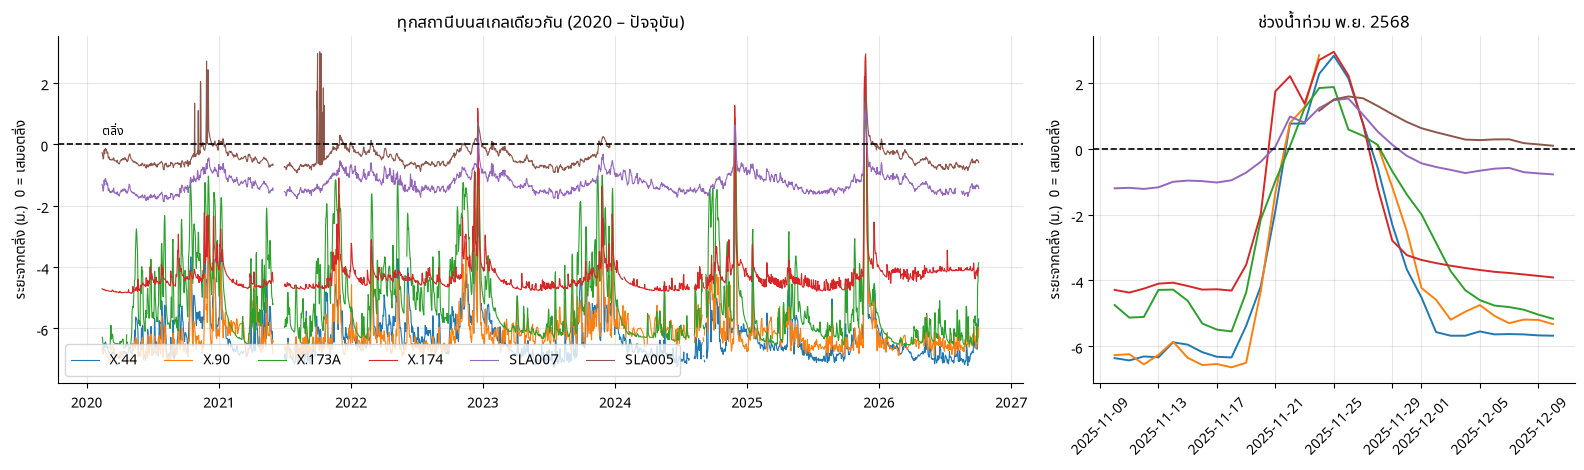

ระยะจากตลิ่งสูงสุดช่วงน้ำท่วม (ม.): {'x44_bank': 2.82, 'x90_bank': 2.84, 'x173a_bank': 1.87, 'x174_bank': 2.94, 'sla007_bank': 1.52, 'sla005_bank': 1.59}


In [4]:
event = slice("2025-11-10", "2025-12-10")
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={"width_ratios": [2, 1]})
for station in STATIONS:
    for ax in axes:
        part = table[f"{minimal.prefix(station)}_bank"]
        part = part.loc[event] if ax is axes[1] else part
        ax.plot(part.index, part, lw=1.4 if ax is axes[1] else 0.8,
                label=station if ax is axes[0] else None)
for ax in axes:
    ax.axhline(0, color="k", lw=1.2, ls="--")
    ax.set_ylabel("ระยะจากตลิ่ง (ม.)  0 = เสมอตลิ่ง")
axes[0].text(table.index[0], 0.3, "ตลิ่ง", fontsize=9)
axes[0].set_title("ทุกสถานีบนสเกลเดียวกัน (2020 – ปัจจุบัน)")
axes[1].set_title("ช่วงน้ำท่วม พ.ย. 2568")
axes[1].tick_params(axis="x", rotation=45)
axes[0].legend(ncol=6, loc="lower left")
plt.tight_layout()
plt.show()

peak = table.loc[event].max().filter(like="_bank").round(2)
print("ระยะจากตลิ่งสูงสุดช่วงน้ำท่วม (ม.):", peak.to_dict())

ช่วงน้ำท่วม พ.ย. 2568 สถานีต้นน้ำล้นตลิ่งก่อนแล้ว X.44 กลางเมืองตามมา — ข้อมูลแบบนี้คือสิ่งที่ LSTM ต้องเรียนรู้

ข้อสังเกต: **SLA005 (ทะเลสาบ) ขาดข้อมูลช่วงปี 2024 ถึง ก.ย. 2568** (เกือบทั้งช่วง validation) วันที่ขาดจะถูกเติมด้วยค่าเฉลี่ยของ train
ตอนป้อนเข้าโมเดล (`lstm.Scaler`)

In [5]:
missing = table.filter(like="_bank").isna().groupby(table.index.year).mean().mul(100).round(0)
missing.rename_axis("ปี").rename(columns=lambda c: c.replace("_bank", "")).astype(int).astype(str) + " %"

,x44,x90,x173a,x174,sla007,sla005
ปี,,,,,,
2020,0 %,0 %,0 %,0 %,0 %,0 %
2021,8 %,8 %,8 %,8 %,8 %,8 %
2022,0 %,0 %,0 %,0 %,0 %,0 %
2023,0 %,0 %,0 %,0 %,0 %,4 %
2024,5 %,5 %,5 %,6 %,0 %,100 %
2025,0 %,1 %,0 %,0 %,0 %,90 %
2026,0 %,0 %,0 %,0 %,5 %,0 %


## 3 · ฝนลุ่มน้ำรายวัน (ERA5)
(`minimal.add_rain`) เฉลี่ยฝนรายชั่วโมงของ 6 จุดกริด → รวมเป็นรายวัน (มม.)

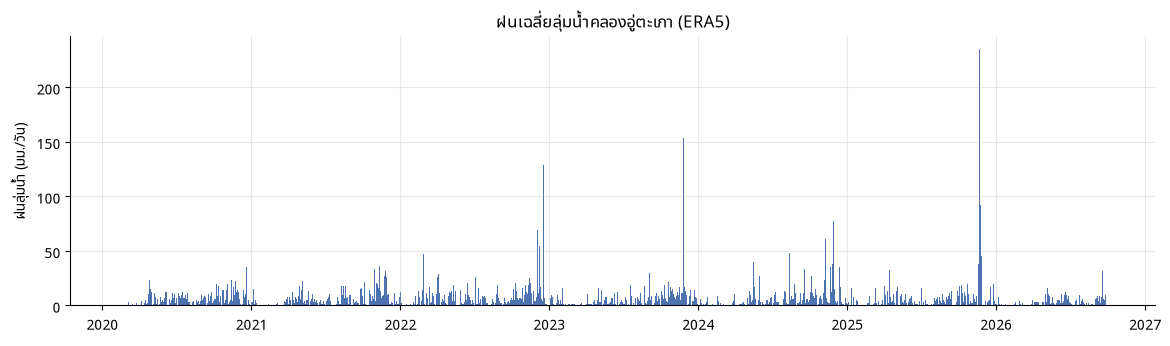

In [6]:
table = minimal.add_rain(table, era5)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(table.index, table["rain"], width=1, color="#4c72b0")
ax.set_ylabel("ฝนลุ่มน้ำ (มม./วัน)")
ax.set_title("ฝนเฉลี่ยลุ่มน้ำคลองอู่ตะเภา (ERA5)")
plt.show()

## 4 · Target: ระดับน้ำ X.44 ล่วงหน้า 1–5 วัน
- `target_h{h}` = ระดับน้ำสูงสุดของ X.44 ในวัน t+h (ม.รทก.)
- `target_delta_h{h}` = target − ระดับวันนี้ = **น้ำจะขึ้น/ลงเท่าไร** — LSTM ทำนายค่านี้แล้วบวกระดับวันนี้กลับ
  เหตุผลอยู่ในหัวข้อ 6
- `minimal.add_targets` สร้าง `era5_rain_next{h}d` (ฝนที่ตกจริงวัน t+1…t+h) ไปพร้อมกันด้วย ใช้ในหัวข้อ 7

In [7]:
table = minimal.add_targets(table)

table[["x44_max", "target_h1", "target_delta_h1", "target_h5", "target_delta_h5"]].loc["2025-11-18":"2025-11-26"].round(2)

,x44_max,target_h1,target_delta_h1,target_h5,target_delta_h5
timestamp,,,,,
2025-11-18,0.81,1.77,0.96,7.91,7.10
2025-11-19,1.77,2.97,1.20,9.42,7.65
2025-11-20,2.97,5.26,2.29,9.97,7.00
2025-11-21,5.26,7.91,2.65,9.28,4.03
2025-11-22,7.91,7.91,0.00,7.90,-0.01
2025-11-23,7.91,9.42,1.51,6.58,-1.34
2025-11-24,9.42,9.97,0.55,4.84,-4.58
2025-11-25,9.97,9.28,-0.69,3.48,-6.49
2025-11-26,9.28,7.90,-1.38,2.63,-6.66


## 5 · แบ่ง train / validation / test ตามเวลา
- **train** 2020-02 → 2024-12 · **validation** ม.ค. → ก.ย. 2568 · **test** ต.ค. 2568 → ปัจจุบัน (มีน้ำท่วม พ.ย. 2568)
- ไม่สุ่ม เพราะวันติดกันคล้ายกันมาก ถ้าสุ่ม โมเดลจะได้เห็นวันข้างๆ ของวันที่ทดสอบ แล้วผลดูดีเกินจริง
- validation ใช้ตัดสินว่าจะหยุดเทรนเมื่อไร (early stopping) · test ใช้วัดผลครั้งเดียวตอนจบ

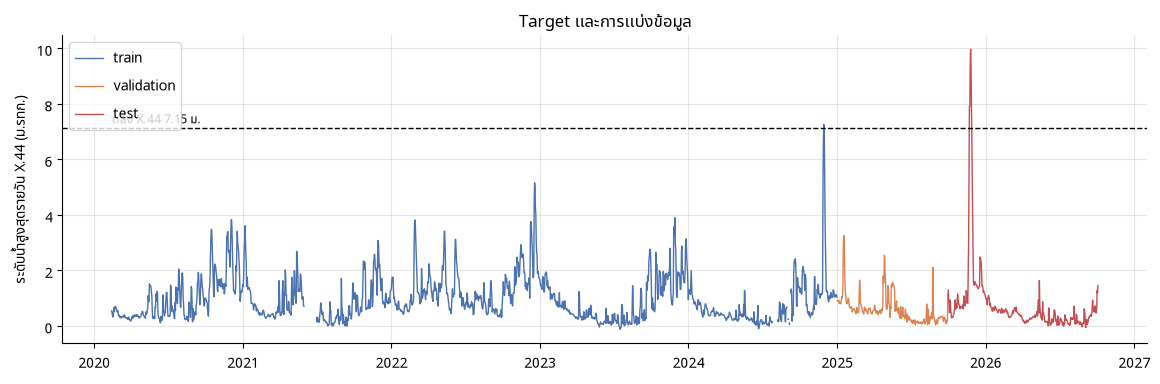

,เริ่ม,ถึง,จำนวนวัน,ระดับสูงสุด,วันน้ำหลาก ≥ 4 ม.,วันล้นตลิ่ง,สัดส่วน %
split,,,,,,,
train,2020-02-13,2024-12-31,1734,7.26,11,1,73.0
validation,2025-01-01,2025-09-30,273,3.26,0,0,11.0
test,2025-10-01,2026-10-04,369,9.97,9,6,16.0


In [8]:
table = minimal.add_split(table)

fig, ax = plt.subplots(figsize=(14, 4))
for split, color in SPLIT_COLORS.items():
    part = table.loc[table["split"] == split, "x44_max"]
    ax.plot(part.index, part, color=color, lw=1, label=split)
ax.axhline(X44_BANK, color="k", ls="--", lw=1)
ax.text(table.index[0], X44_BANK + 0.15, f"ตลิ่ง X.44 {X44_BANK} ม.", fontsize=9)
ax.set_ylabel("ระดับน้ำสูงสุดรายวัน X.44 (ม.รทก.)")
ax.set_title("Target และการแบ่งข้อมูล")
ax.legend(loc="upper left")
plt.show()

known = table.dropna(subset=["x44_max"])
summary = known.groupby("split").agg(**{
    "เริ่ม": ("x44_max", lambda s: s.index.min().date()),
    "ถึง": ("x44_max", lambda s: s.index.max().date()),
    "จำนวนวัน": ("x44_max", "size"),
    "ระดับสูงสุด": ("x44_max", "max"),
    "วันน้ำหลาก ≥ 4 ม.": ("x44_max", lambda s: int((s >= 4).sum())),
    "วันล้นตลิ่ง": ("x44_max", lambda s: int((s >= X44_BANK).sum())),
}).loc[["train", "validation", "test"]]
summary["สัดส่วน %"] = (100 * summary["จำนวนวัน"] / summary["จำนวนวัน"].sum()).round(0)
summary

## 6 · ปัญหา: test มีน้ำสูงกว่าทุกอย่างที่ train เคยเห็น
- train สูงสุด **7.26 ม.** (ปี 2567) แต่ test พีค **9.97 ม.**
- ถ้าให้โมเดลทำนายระดับน้ำตรงๆ โมเดลมักทำนายไม่เกินช่วงที่เคยเห็น
- **ทางแก้:** ทำนาย "น้ำจะขึ้นอีกเท่าไรจากวันนี้" (`target_delta`) แล้วบวกระดับวันนี้กลับ
  วันที่ 24 พ.ย. 2568 น้ำอยู่ที่ ~9 ม. แล้ว โมเดลแค่ต้องทำนายว่าจะขึ้นอีก ~1 ม.
- **ข้อจำกัดที่ต้องรู้:** validation (ม.ค.–ก.ย. 2568) **ไม่มีวันน้ำหลากเลย** early stopping จึงตัดสินจากวันน้ำปกติเป็นหลัก

## 7 · ฝนอนาคต t+1 … t+h
ฝนที่จะตกในอีกไม่กี่วันข้างหน้าสำคัญมาก เพราะน้ำจากต้นน้ำมาถึงเมืองก่อนแค่ไม่ถึง 1 วัน
ถ้าไม่รู้ฝนล่วงหน้า ทำนาย 3–5 วันได้แค่ "เท่าวันนี้"

| ช่วง | ฝนอนาคตที่ป้อนให้โมเดล | เหตุผล |
|---|---|---|
| train (2563–2567) | ฝน **ERA5 ที่ตกจริง** | พยากรณ์ย้อนหลังมีแค่ตั้งแต่ มี.ค. 2567 ไม่พอเทรน ("perfect prognosis") |
| validation, test | **พยากรณ์ GFS** × ตัวคูณแก้ bias | เหมือนการใช้งานจริง |

- ใช้พยากรณ์ที่ออก **เก่ากว่า 1 วัน** (`FORECAST_LEAD_OFFSET`) เพราะตอนสิ้นวัน t พยากรณ์รอบล่าสุดอาจยังไม่ออก
- GFS ให้ฝนน้อยกว่าจริง → คูณด้วย (ฝนจริงรวม / ฝนพยากรณ์รวม) ช่วง มี.ค.–ธ.ค. 2567 ซึ่งอยู่ใน train จึงไม่ได้แอบดู test

In [9]:
# พยากรณ์ GFS ฝนรวมวัน t+1..t+h (ยังไม่แก้ bias) → gfs_raw_rain_next{h}d
nwp_daily = features.nwp_daily_rain(nwp_rain)
table = minimal.add_gfs_rain(table, nwp_daily)

# ตัวคูณ = ฝนจริงรวม / ฝนพยากรณ์รวม ช่วง มี.ค.–ธ.ค. 2567
SCALE = minimal.gfs_bias_scale(table)
pandas.Series(SCALE, name="ตัวคูณแก้ bias GFS").rename_axis("h").round(2).to_frame().T

h,1,2,3,4,5
ตัวคูณแก้ bias GFS,1.35,1.38,1.38,1.58,1.75


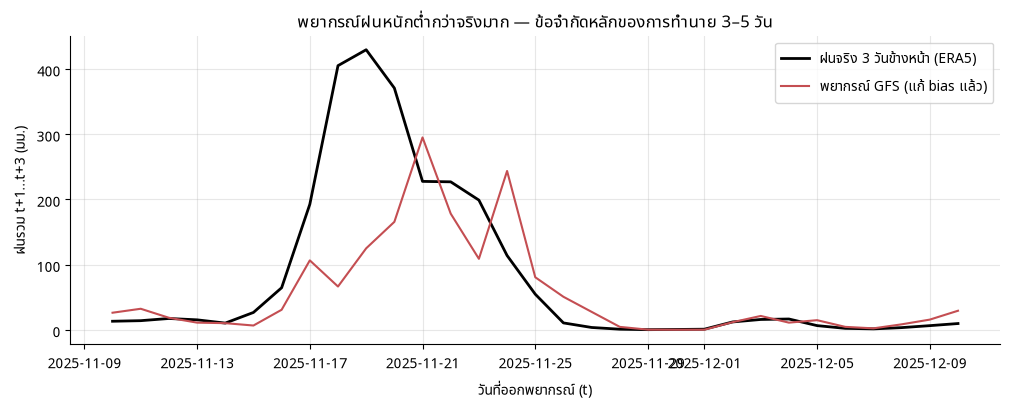

In [10]:
# gfs_rain_next = พยากรณ์ × ตัวคูณ; rain_next (input โมเดล) = ERA5 ใน train, GFS นอก train
table = minimal.add_rain_next(table, SCALE)

# พยากรณ์ 3 วันเทียบฝนจริง ช่วงน้ำท่วม
fig, ax = plt.subplots(figsize=(12, 4))
part = table.loc[event]
ax.plot(part.index, part["era5_rain_next3d"], color="k", lw=2, label="ฝนจริง 3 วันข้างหน้า (ERA5)")
ax.plot(part.index, part["gfs_rain_next3d"], color="#c44e52", lw=1.5, label="พยากรณ์ GFS (แก้ bias แล้ว)")
ax.set_ylabel("ฝนรวม t+1…t+3 (มม.)")
ax.set_xlabel("วันที่ออกพยากรณ์ (t)")
ax.set_title("พยากรณ์ฝนหนักต่ำกว่าจริงมาก — ข้อจำกัดหลักของการทำนาย 3–5 วัน")
ax.legend()
plt.show()

## 8 · ตารางสุดท้าย → `data/processed/minimal_daily.parquet`

In [11]:
FEATURES, RAIN_NEXT = minimal.FEATURES, minimal.RAIN_NEXT

table.to_parquet(PROCESSED / "minimal_daily.parquet")
print(f"{len(table):,} วัน ({table.index.min():%Y-%m-%d} ถึง {table.index.max():%Y-%m-%d})")
print(f"input ต่อวัน ({len(FEATURES)}):", FEATURES)
print("ฝนอนาคต:", RAIN_NEXT)
print("target:", [f"target_h{h}" for h in HORIZONS])
table[FEATURES + RAIN_NEXT + ["x44_max", "target_h1", "split"]].loc["2025-11-20":"2025-11-25"].round(2)

2,426 วัน (2020-02-13 ถึง 2026-10-04)
input ต่อวัน (7): ['x44_bank', 'x90_bank', 'x173a_bank', 'x174_bank', 'sla007_bank', 'sla005_bank', 'rain']
ฝนอนาคต: ['rain_next1d', 'rain_next2d', 'rain_next3d', 'rain_next4d', 'rain_next5d']
target: ['target_h1', 'target_h2', 'target_h3', 'target_h4', 'target_h5']


,x44_bank,x90_bank,x173a_bank,x174_bank,sla007_bank,sla005_bank,rain,rain_next1d,rain_next2d,rain_next3d,rain_next4d,rain_next5d,x44_max,target_h1,split
timestamp,,,,,,,,,,,,,,,
2025-11-20,-4.18,-4.33,-2.15,-1.99,-0.40,NaN,131.57,18.28,42.03,165.53,194.44,222.68,2.97,5.26,test
2025-11-21,-1.89,-1.34,-0.98,1.74,0.06,NaN,235.33,41.73,188.42,295.05,360.18,404.56,5.26,7.91,test
2025-11-22,0.76,0.78,0.07,2.20,0.97,NaN,62.67,112.21,144.48,178.12,213.03,242.87,7.91,7.91,test
2025-11-23,0.76,1.26,1.23,1.37,0.79,NaN,72.80,41.59,81.61,108.83,149.46,167.67,7.91,9.42,test
2025-11-24,2.27,2.84,1.84,2.69,1.23,1.15,92.15,100.25,121.70,243.59,279.13,310.66,9.42,9.97,test
2025-11-25,2.82,NaN,1.87,2.94,1.47,1.49,62.00,63.28,77.80,80.57,96.58,108.61,9.97,9.28,test
